In [1]:
# 0,1: 00 for psi_1, 01 for psi_2 ...
# 2,3,4: For states
# 5,6: Ancillary qubits

In [2]:
from qiskit import QuantumCircuit
from numpy import sqrt
from qiskit.circuit.library import StatePreparation
def circuit_init():
    qc = QuantumCircuit(7)
    return qc

def PREP(qc):

    desired_vector = [
        1 / sqrt(3), 0, 0, 0, 0, 0, 0, 0,
        -1 / (8 * sqrt(3)), -1 / 8, -1 / 8, -sqrt(3) / 8,
        -1 / 8, -sqrt(3) / 8, -sqrt(3) / 8, -3 / 8,
        -1 / (8 * sqrt(3)), 1 / 8, 1 / 8, -sqrt(3) / 8,
        1 / 8, -sqrt(3) / 8, -sqrt(3) / 8, 3 / 8,
        0, 0, 0, 0, 0, 0, 0, 0
    ]
    prep = StatePreparation(desired_vector)
    qc.append(prep,[4,3,2,1,0])
    return qc

In [3]:
from pennylane.templates.state_preparations.mottonen import compute_theta, gray_code
from qiskit.circuit.library.standard_gates import RXGate,RYGate, RZGate
from qiskit.circuit.library import MCXGate
from qiskit.circuit.library.standard_gates import XGate
from numpy import array, log2

def RRR_X(qc, wires, params):
    qc.append(RXGate(params[0]),[wires[0]])
    qc.append(RXGate(params[1]),[wires[1]])
    qc.append(RXGate(params[2]),[wires[2]])
    
def RRR_Z(qc, wires, params):
    qc.append(RZGate(params[0]),[wires[0]])
    qc.append(RZGate(params[1]),[wires[1]])
    qc.append(RZGate(params[2]),[wires[2]])


def U_CCCR_decom(qc,wires,params):
    # Make sure that control qubits should be increasing order
    params = array(params)
    params = compute_theta(params) #can be on/off

    num_Ucontrols = len(wires)-1
    code = gray_code(3)
    n_selections = len(code)
    control_order = [int(log2(int(code[i], 2) ^ int(code[(i + 1) % n_selections], 2))) for i in range(n_selections)]

    for i in range(n_selections):
        qc.ry(params[i],wires[3])
        qc.cx(wires[num_Ucontrols-1 - control_order[i]],wires[3])   
    return qc


def CRRR_X(qc, wires, state, params):
    qc.append(RXGate(params[0]).control(1,ctrl_state = state[::-1]), [wires[0], wires[1]])  # Control: wires[0] Target: wires[1]
    qc.append(RXGate(params[1]).control(1,ctrl_state = state[::-1]), [wires[0], wires[2]])  # Control: wires[0] Target: wires[2]
    qc.append(RXGate(params[2]).control(1,ctrl_state = state[::-1]), [wires[0], wires[3]])  # Control: wires[0] Target: wires[3]
    return qc

def CRRR_Z(qc, wires, state, params):
    qc.append(RZGate(params[0]).control(1,ctrl_state = state[::-1]), [wires[0], wires[1]])  # Control: wires[0] Target: wires[1]
    qc.append(RZGate(params[1]).control(1,ctrl_state = state[::-1]), [wires[0], wires[2]])  # Control: wires[0] Target: wires[2]
    qc.append(RZGate(params[2]).control(1,ctrl_state = state[::-1]), [wires[0], wires[3]])  # Control: wires[0] Target: wires[2]
    return qc

def U_CCCcR_decom(qc,wires,params):
    # Make sure that control qubits should be increasing order
    params = array(params)
    params = compute_theta(params) #can be on/off

    num_Ucontrols = len(wires)-2
    code = gray_code(3)
    n_selections = len(code)
    control_order = [int(log2(int(code[i], 2) ^ int(code[(i + 1) % n_selections], 2))) for i in range(n_selections)]

    for i in range(n_selections):
        qc.cry(params[i],wires[3],wires[4])
        CCX(qc,[wires[num_Ucontrols-1 - control_order[i]],wires[3],wires[4]],'11')
    
    return qc

def CCRRR_X(qc, wires, state, params):
    qc.append(RXGate(params[0]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[2]])  # Control: wires[0] wires[1]
    qc.append(RXGate(params[1]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[3]])  # Control: wires[0] wires[1]
    qc.append(RXGate(params[2]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[4]])  # Control: wires[0] wires[1]
    return qc

def CCRRR_Z(qc, wires, state, params):
    qc.append(RZGate(params[0]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[2]])  # Control: wires[0] wires[1]
    qc.append(RZGate(params[1]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[3]])  # Control: wires[0] wires[1]
    qc.append(RZGate(params[2]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[4]])  # Control: wires[0] wires[1]
    return qc

def CCX(qc, wires, state):
    mcx_gate = MCXGate(num_ctrl_qubits=2,ctrl_state=state[::-1])
    qc.append(mcx_gate, [wires[0], wires[1],wires[2]])
    return qc

def CCCX(qc, wires, state):
    mcx_gate = MCXGate(num_ctrl_qubits=3,ctrl_state=state[::-1])
    qc.append(mcx_gate, [wires[0], wires[1],wires[2], wires[3]])
    return qc


def CX01(qc, wires):
    qc.append(XGate().control(1, ctrl_state='1'),[wires[0], wires[1]])
    return qc

In [4]:
def Ansatz(qc, wires, params):


    #Big made by HEA 
    RRR_X(qc,wires[0:3],params[0:3])
    RRR_Z(qc,wires[0:3],params[3:6])
    qc.cx(wires[0],wires[1])
    qc.cx(wires[1],wires[2])

    #Module 1
    U_CCCR_decom(qc,wires[0:4],params[6:14])
    CRRR_X(qc,[wires[3],wires[0],wires[1],wires[2]],'0',params[14:17])
    CRRR_Z(qc,[wires[3],wires[0],wires[1],wires[2]],'0',params[17:20])
    CCX(qc,[wires[0],wires[3], wires[1]],'10')
    CCX(qc,[wires[1],wires[3], wires[2]],'10')

    CRRR_X(qc,[wires[3],wires[0],wires[1],wires[2]],'1',params[20:23])
    CRRR_Z(qc,[wires[3],wires[0],wires[1],wires[2]],'1',params[23:26])
    CCX(qc,[wires[0],wires[3], wires[1]],'11')
    CCX(qc,[wires[1],wires[3], wires[2]],'11')

    #Module 2
    U_CCCcR_decom(qc, wires[0:5],params[26:34])
    CCRRR_X(qc,[wires[3],wires[4],wires[0],wires[1],wires[2]],'10',params[34:37])
    CCRRR_Z(qc,[wires[3],wires[4],wires[0],wires[1],wires[2]],'10',params[37:40])
    CCCX(qc,[wires[0],wires[3],wires[4],wires[1]],'110')
    CCCX(qc,[wires[1],wires[3],wires[4],wires[2]],'110')
    CCRRR_X(qc,[wires[3],wires[4],wires[0],wires[1],wires[2]],'11',params[40:43])
    CCRRR_Z(qc,[wires[3],wires[4],wires[0],wires[1],wires[2]],'11',params[43:46])
    CCCX(qc,[wires[0],wires[3],wires[4],wires[1]],'111')
    CCCX(qc,[wires[1],wires[3],wires[4],wires[2]],'111')    
    
    CX01(qc, [wires[4],wires[3]])
    qc.measure_all()
    return qc

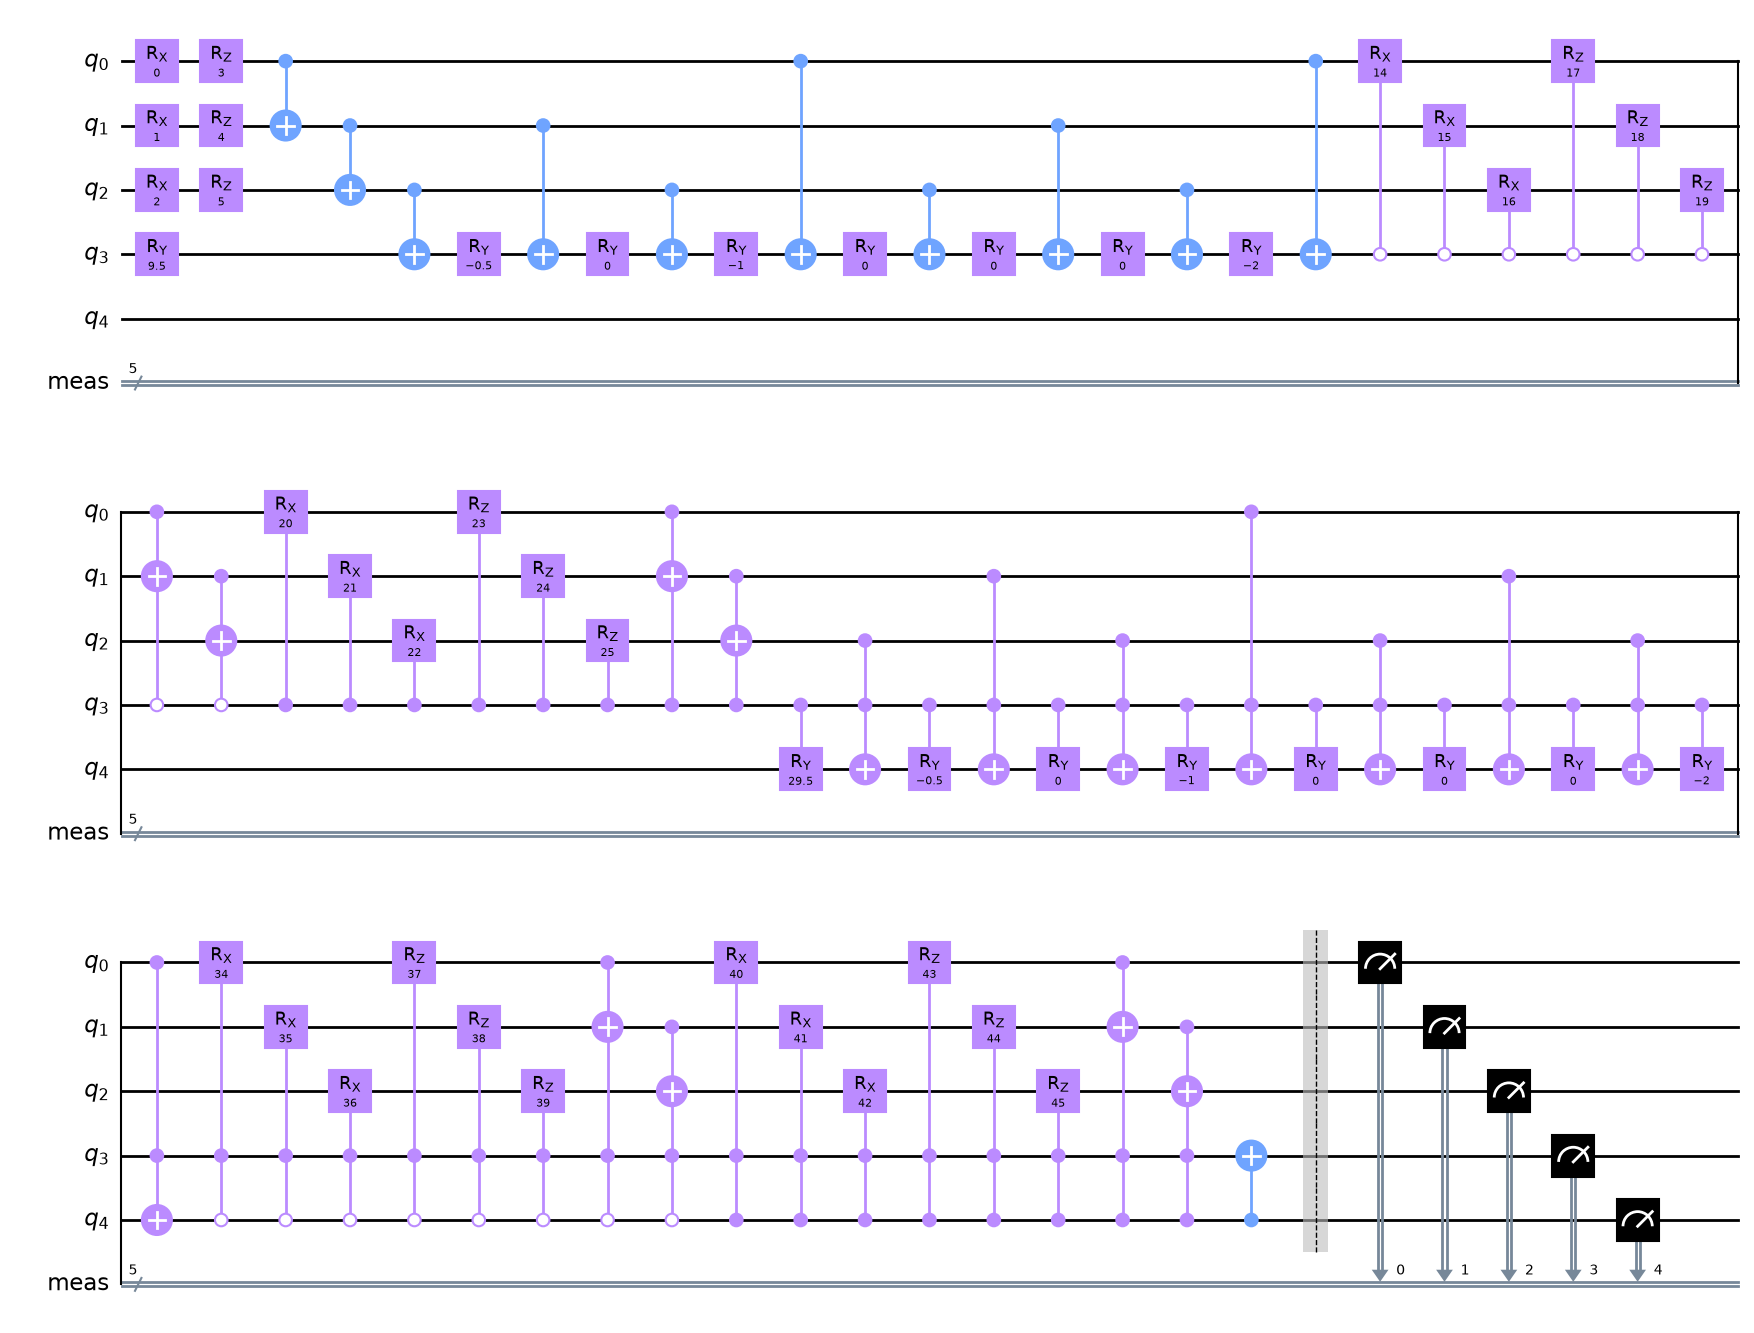

In [5]:
from numpy.random import rand
num_params=46
#params = rand(num_params)
params = list(range(num_params))
qc = QuantumCircuit(5)
#PREP(qc)
Ansatz(qc, [0,1,2,3,4] , params)
qc.draw(output='mpl', style = 'clifford')

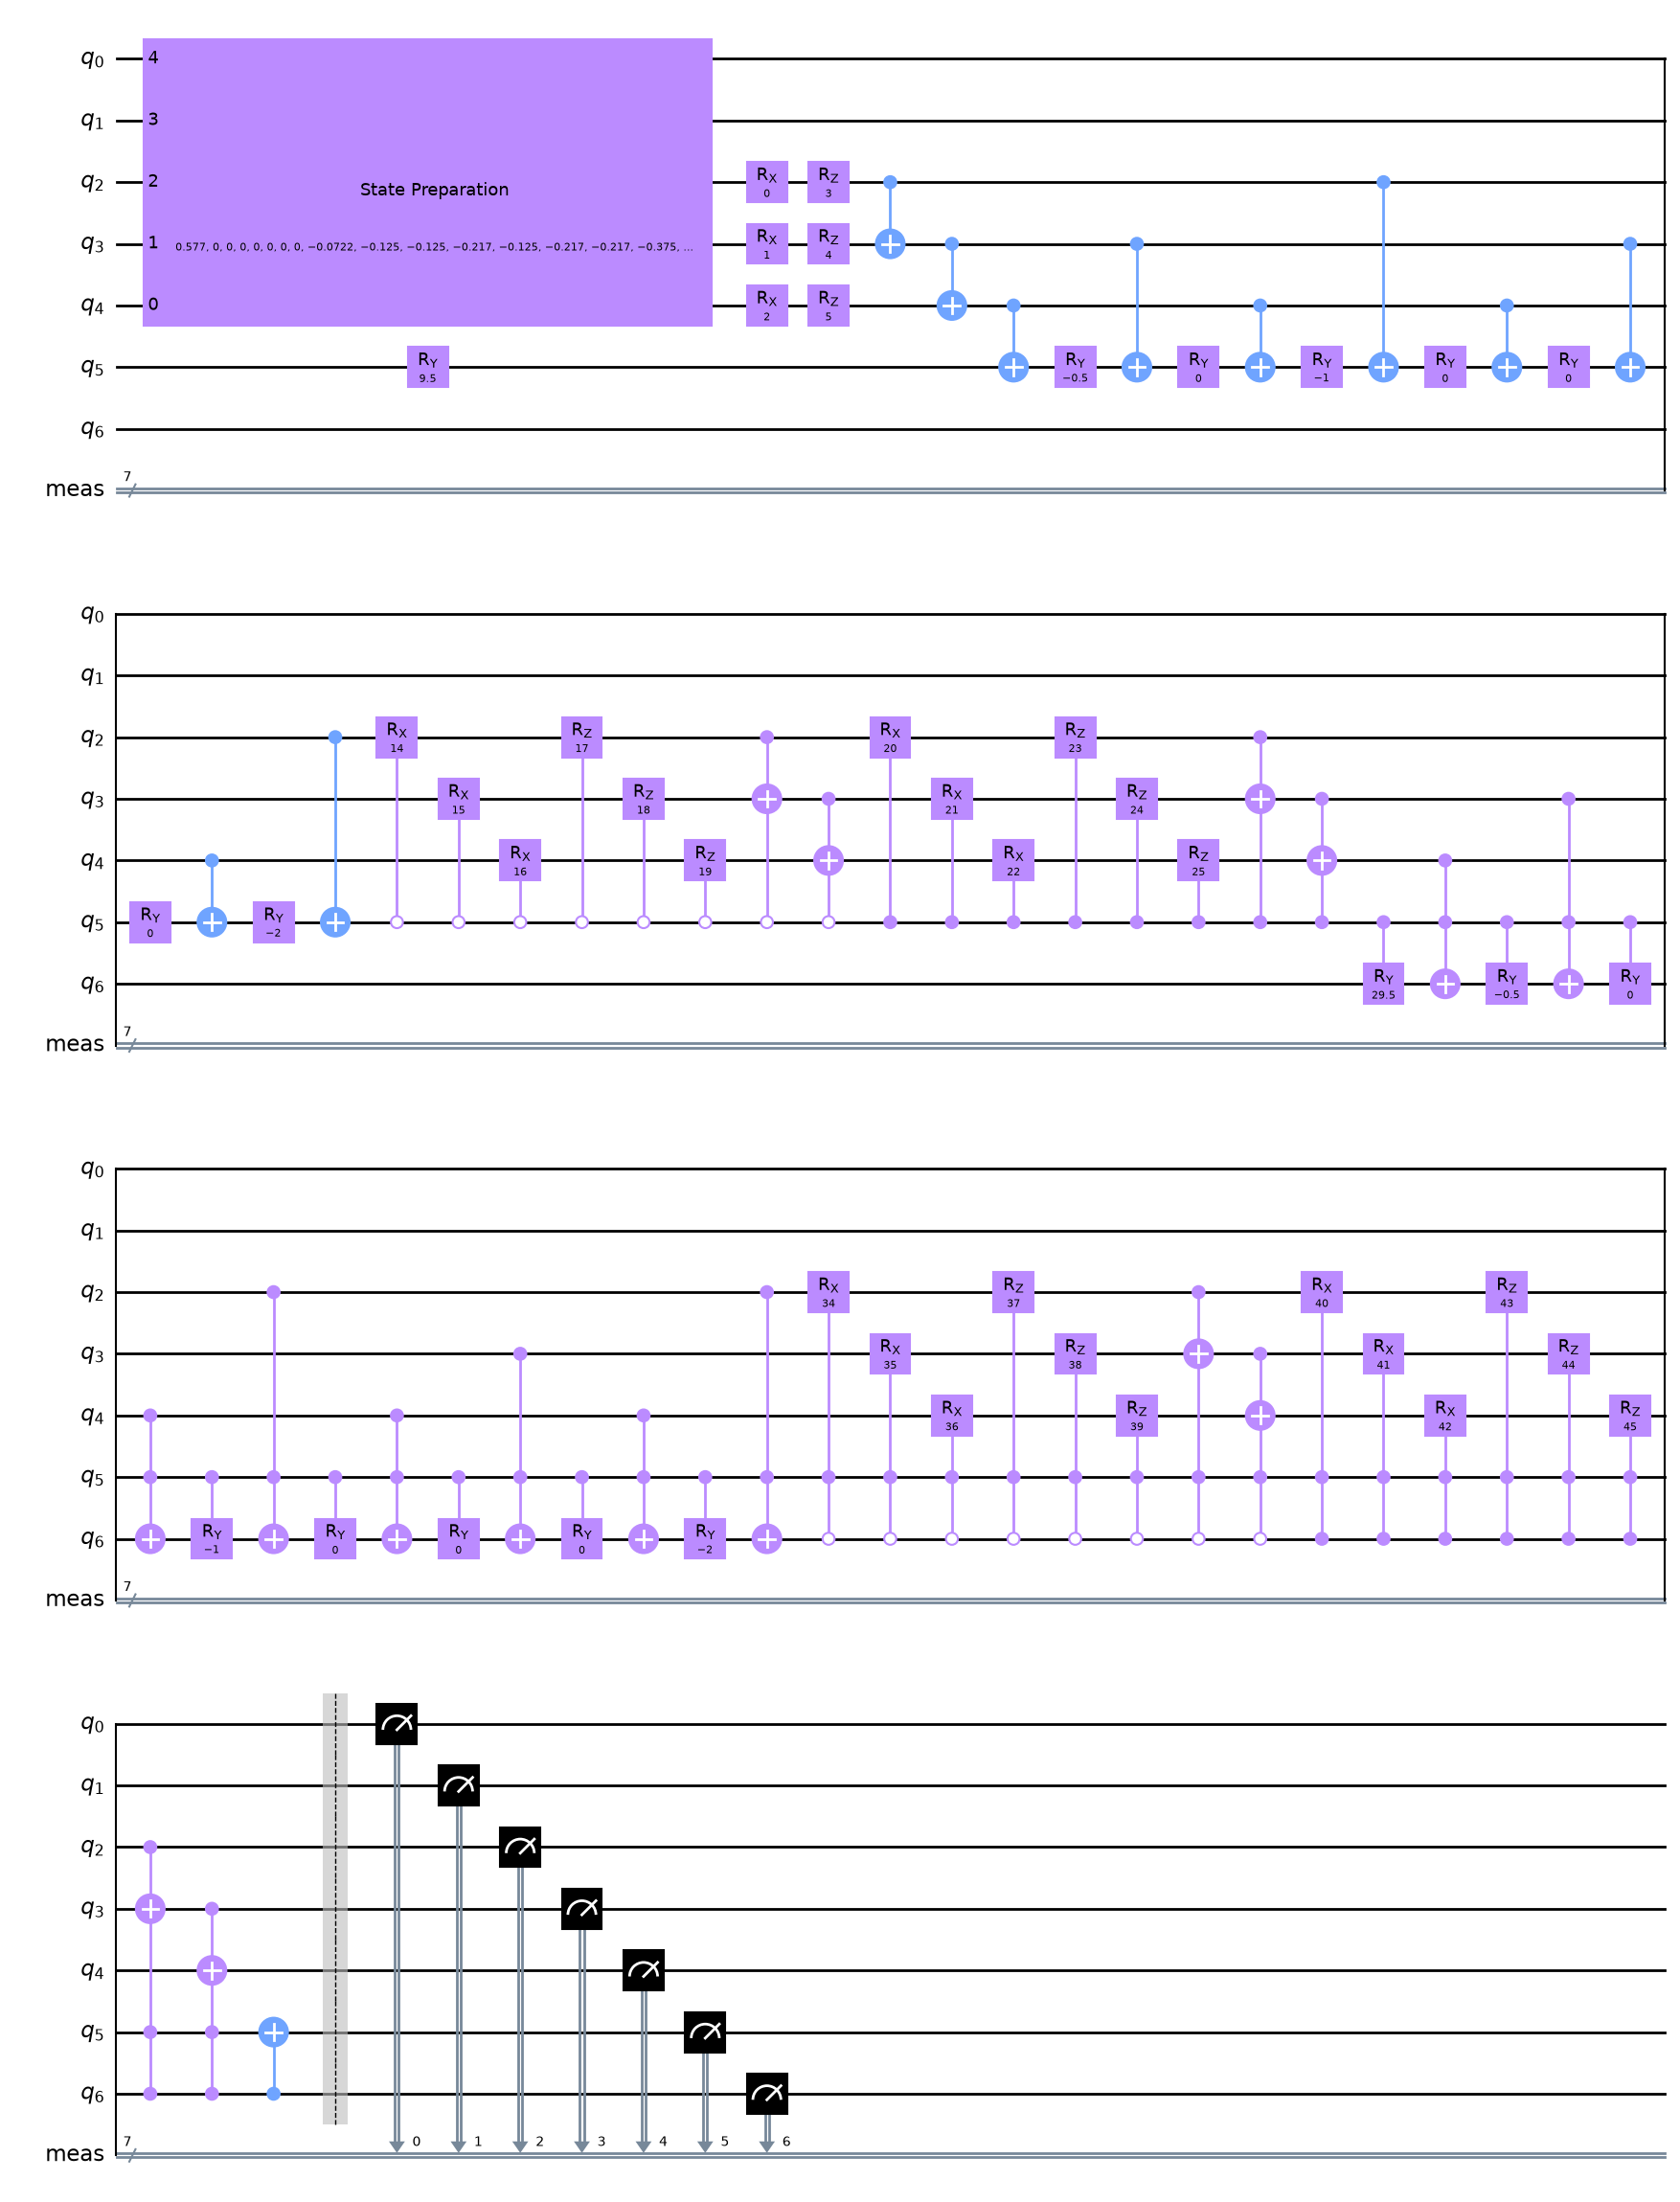

In [6]:
from numpy.random import rand
num_shots=10000
num_params=46
params = list(range(num_params))
qc = circuit_init()
PREP(qc)
Ansatz(qc, [2,3,4,5,6], params)
qc.draw(output='mpl', style = 'clifford') 

In [7]:
# ============================================================
# AWS Braket / IQM Garnet setup
# ============================================================

from braket.aws import AwsDevice
from qiskit_braket_provider import BraketProvider
from qiskit import transpile
import numpy as np

GARNET_ARN = "arn:aws:braket:eu-north-1::device/qpu/iqm/Garnet"

# Check device status. This does NOT submit a paid task.
garnet_device = AwsDevice(GARNET_ARN)

print("Device name   :", garnet_device.name)
print("Device status :", garnet_device.status)

try:
    qd = garnet_device.queue_depth()
    print("Quantum-task queue :", qd.quantum_tasks)
    print("Hybrid-job queue   :", qd.jobs)
except Exception as exc:
    print("Queue depth unavailable:", exc)

provider = BraketProvider()
garnet_backend = provider.get_backend("Garnet")

print("Qiskit-Braket backend:", garnet_backend)

HARDWARE_RUN = True

Device name   : Garnet
Device status : ONLINE
Quantum-task queue : {<QueueType.NORMAL: 'Normal'>: '0', <QueueType.PRIORITY: 'Priority'>: '0'}
Hybrid-job queue   : 0
Qiskit-Braket backend: BraketBackend[Garnet]


In [8]:
# ============================================================
# Fixed optimal parameters
# ============================================================
import numpy as np
num_params = 46

optimal_params = np.array([
 5.4195490664e-03, -6.2506045947e-03,  1.0694487195e-02,
  1.5729284758e+00, -3.3599200118e-02,  1.6118828369e+00,
  7.0626125208e-04,  2.2221227797e+00,  3.0697027600e+00,
  2.5675512406e+00,  3.1966998788e+00,  3.1360917407e+00,
  3.2244019255e+00,  3.1318450024e+00,  2.2970949187e-01,
 -1.5684284465e+00,  1.6651495763e+00,  1.3599538159e-01,
  1.9673590114e-01,  7.5022113355e-01,  1.5695563619e+00,
  5.9428146187e-01,  1.5603188171e+00,  2.1059999096e+00,
  9.3222593831e-01,  2.3071491715e-01,  3.1270523664e+00,
 -3.7104653253e-02,  3.2337815824e+00, -4.7171224825e-02,
 -2.9229637644e+00,  9.3578023103e-02, -1.0842981228e-01,
  2.9819818005e+00, -1.0921747099e+00,  5.8142177631e-01,
  2.4090577519e-01,  1.6556705187e+00,  7.3251287111e-01,
  2.5608858058e-01,  1.2390870545e+00,  2.1896946461e+00,
  1.0327679784e+00,  2.9188767504e-01,  3.1632765570e-02,
 -1.7150642393e+00
], dtype=float)

assert len(optimal_params) == num_params

print("Number of parameters :", len(optimal_params))

Number of parameters : 46


In [9]:
# ============================================================
# Debug with AerSimulator
# ============================================================

from qiskit_aer import AerSimulator
from qiskit import transpile

debug_shots = 100000
debug_seed = 150

aersim = AerSimulator()


# ------------------------------------------------------------
# Construct circuit
# ------------------------------------------------------------

qc_debug = circuit_init()

PREP(qc_debug)

Ansatz(
    qc_debug,
    wires=[2, 3, 4, 5, 6],
    params=optimal_params
)

qc_debug = qc_debug.reverse_bits()


# ------------------------------------------------------------
# Transpile and run
# ------------------------------------------------------------

t_qc_debug = transpile(
    qc_debug,
    backend=aersim,
    optimization_level=3,
    seed_transpiler=debug_seed
)

job_debug = aersim.run(
    t_qc_debug,
    shots=debug_shots,
    seed_simulator=debug_seed
)

result_debug = job_debug.result()
counts_debug = result_debug.get_counts()


# ------------------------------------------------------------
# Existing target-count mapping
# ------------------------------------------------------------

tar_00 = 0
tar_01 = 0
tar_10 = 0

for outcome, count in counts_debug.items():

    if outcome[0:2] == "00":
        if outcome[5:7] == "00":
            tar_00 += count

    if outcome[0:2] == "01":
        if outcome[5:7] == "01":
            tar_01 += count

    if outcome[0:2] == "10":
        if outcome[5:7] == "10":
            tar_10 += count


p_suc_debug = (
    tar_00
    + tar_01
    + tar_10
) / debug_shots


print("\n=== AerSimulator debug result ===")
print("tar_00 :", tar_00)
print("tar_01 :", tar_01)
print("tar_10 :", tar_10)
print("Success probability :", p_suc_debug)


=== AerSimulator debug result ===
tar_00 : 33458
tar_01 : 31871
tar_10 : 32228
Success probability : 0.97557


In [10]:
# ============================================================
# IQM Garnet: one run with optimal parameters
# ============================================================

import time

num_shots = 10000
seed_transpiler = 150


# ------------------------------------------------------------
# Construct actual circuit
# ------------------------------------------------------------

qc = circuit_init()

PREP(qc)

Ansatz(
    qc,
    wires=[2, 3, 4, 5, 6],
    params=optimal_params
)

qc_reverse = qc.reverse_bits()


# ------------------------------------------------------------
# Transpile for IQM Garnet
# ------------------------------------------------------------

t_qc = transpile(
    qc_reverse,
    backend=garnet_backend,
    optimization_level=3,
    seed_transpiler=seed_transpiler
)


# ============================================================
# IQM Garnet transpiled resource report
# ============================================================

op_counts = dict(t_qc.count_ops())

one_q = 0
two_q = 0
multi_q = 0
measurements = 0

for item in t_qc.data:

    name = item.operation.name
    nq = len(item.qubits)

    if name == "measure":
        measurements += 1
    elif nq == 1:
        one_q += 1
    elif nq == 2:
        two_q += 1
    elif nq > 2:
        multi_q += 1


print("\n=== IQM Garnet transpiled resource report ===")
print(f"{'num_qubits':22s}: {t_qc.num_qubits}")
print(f"{'depth':22s}: {t_qc.depth()}")
print(f"{'size':22s}: {t_qc.size()}")
print(f"{'1q_gate_count':22s}: {one_q}")
print(f"{'2q_gate_count':22s}: {two_q}")
print(f"{'multiq_gate_count':22s}: {multi_q}")
print(f"{'measurement_count':22s}: {measurements}")
print(f"{'cz_count':22s}: {int(op_counts.get('cz', 0))}")
print(f"{'cx_count':22s}: {int(op_counts.get('cx', 0))}")
print(f"{'operation_counts':22s}: {op_counts}")


# ============================================================
# Submit ONE paid QPU task
# ============================================================

if HARDWARE_RUN:

    start_time = time.perf_counter()

    job = garnet_backend.run(
        t_qc,
        shots=num_shots,
        verbatim=True
    )

    print("\nBraket task ID:")
    print(job.job_id())

    print("\nWaiting for result...")

    result = job.result()

    end_time = time.perf_counter()

    print("Task wall time:", end_time - start_time, "s")


    # --------------------------------------------------------
    # Counts
    # --------------------------------------------------------

    counts = result.get_counts()

    print("\nCounts:")
    print(counts)


    # --------------------------------------------------------
    # Existing target-count mapping
    # --------------------------------------------------------

    tar_00 = 0
    tar_01 = 0
    tar_10 = 0

    for outcome, count in counts.items():

        if outcome[0:2] == "00":
            if outcome[5:7] == "00":
                tar_00 += count

        if outcome[0:2] == "01":
            if outcome[5:7] == "01":
                tar_01 += count

        if outcome[0:2] == "10":
            if outcome[5:7] == "10":
                tar_10 += count


    p_suc = (
        tar_00
        + tar_01
        + tar_10
    ) / num_shots


    print("\n=== Garnet result ===")
    print("tar_00 :", tar_00)
    print("tar_01 :", tar_01)
    print("tar_10 :", tar_10)
    print("Success probability :", p_suc)


=== IQM Garnet transpiled resource report ===
num_qubits            : 20
depth                 : 939
size                  : 1577
1q_gate_count         : 1180
2q_gate_count         : 390
multiq_gate_count     : 1
measurement_count     : 7
cz_count              : 390
cx_count              : 0
operation_counts      : {'r': 1180, 'cz': 390, 'measure': 7, 'barrier': 1}


/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Barrier is not included in the current Target and will be ignored.
  _translate_to_braket(
/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 5.497787143781777 will not be included in Braket circuit
  _translate_to_braket(



Braket task ID:
arn:aws:braket:eu-north-1:082674088760:quantum-task/d245d88a-32e1-4203-9f61-7be40f4fd66b

Waiting for result...
Task wall time: 17.698656749998918 s

Counts:
{'0001011': 134, '0010100': 214, '0011011': 140, '0001001': 114, '1110111': 17, '0001111': 146, '0100110': 62, '1110000': 22, '0000110': 279, '0011111': 109, '0011100': 160, '1011100': 62, '0111101': 21, '1100010': 17, '1000011': 77, '0011000': 174, '0010110': 233, '1011001': 50, '0000100': 270, '0110010': 61, '0110011': 44, '0001000': 185, '0100100': 67, '0001100': 172, '0000001': 163, '0000000': 279, '1001101': 38, '0011110': 139, '0110101': 34, '0011010': 183, '0111001': 16, '0110100': 58, '1000010': 129, '0100010': 79, '0000011': 222, '1000000': 108, '0000010': 288, '1010010': 89, '1010101': 53, '1011101': 40, '1000100': 106, '0010000': 247, '1011010': 66, '1011110': 54, '0001110': 147, '1001110': 80, '0100111': 65, '0101000': 46, '0010001': 130, '0100011': 56, '1000111': 82, '0100000': 64, '1001010': 72, '110